# Machine Learning Modeling

The objective of this phase is to develop predictive models capable of distinguishing fraudulent transactions from legitimate ones.

The following algorithms are implemented:

Logistic Regression
Random Forest
XGBoost

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("credit_card.csv")

In [3]:
df['day'] = (df['step'] - 1) // 24 + 1
df['hour'] = (df['step'] - 1) % 24+1

In [4]:
df_model = df.copy()
df_model.drop(columns=['step','isFlaggedFraud',
        'nameOrig','nameDest'],inplace=True)
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,day,hour
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,1,1
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1,1
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,1,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,1,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,1,1


In [5]:
X = df_model.drop("isFraud", axis=1)
y = df_model["isFraud"]
print(X.shape)
print(y.shape)
X.head()

(6362620, 8)
(6362620,)


,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,day,hour
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,1,1
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,1,1
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,1
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,1
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,1,1


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
    stratify=y,random_state=42)
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (5090096, 8)
Testing Shape  : (1272524, 8)


In [8]:
numeric_features = ["amount","oldbalanceOrg","newbalanceOrig",
    "oldbalanceDest", "newbalanceDest","day","hour"]
categorical_features = ["type"]

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [10]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

In [11]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)],
    remainder="passthrough"
)

In [12]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [13]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

## Logistic Regression

Logistic Regression is used as a baseline linear classification model. Due to class imbalance, SMOTE is applied to the training data.

In [14]:
from sklearn.linear_model import LogisticRegression
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        ("smote", SMOTE(random_state=42)),
        ("model",LogisticRegression(random_state=42,max_iter=1000))
          ]
)

In [15]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest', 'day',
                                                   'hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [16]:
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:,1]

## Random Forest

Random Forest is an ensemble learning algorithm capable of capturing complex non-linear relationships while being robust to overfitting.

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor_tree),
        ("model",RandomForestClassifier(n_estimators=50,
                max_depth=15,class_weight="balanced",
                random_state=42,n_jobs=-1))
         ]
)

In [42]:
rf_pipeline.fit(X_train, y_train)

C:\Users\MY PC\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=50, n_jobs=-1,
                                        random_state=42))])

In [19]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

## XGBoost

XGBoost is a gradient boosting algorithm designed for high predictive performance and efficient handling of imbalanced datasets.

In [20]:
!pip install xgboost

In [21]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

773.7482496194825


In [22]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor_tree),
        ("model",XGBClassifier(random_state=42,
                eval_metric="logloss",tree_method="hist",
                scale_pos_weight=scale_pos_weight,
                learning_rate=0.1,n_estimators=100,
                max_depth=6,n_jobs=-1))
          ]
)

In [23]:
xgb_pipeline.fit(X_train, y_train)

C:\Users\MY PC\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_m...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [24]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

# Model Evaluation

Model performance is evaluated using:

Accuracy
Precision
Recall
F1-score
ROC-AUC

In [25]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Random Forest",
              "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9540,0.0262,0.9580,0.0510,0.9917
1,Random Forest,0.9958,0.2301,0.9647,0.3716,0.9989
2,XGBoost,0.9939,0.1747,0.9957,0.2973,0.9998


## Overall interpretation

All three baseline models achieved very high ROC-AUC values (>0.99), indicating excellent ability to distinguish fraudulent from legitimate transactions.

However, because the dataset is highly imbalanced, accuracy is not an appropriate performance measure. A model can achieve very high accuracy simply by correctly classifying the abundant legitimate transactions.

Recall is high for all three models, meaning they successfully identify most fraudulent transactions.

Precision is low, indicating that many legitimate transactions are incorrectly classified as fraud, leading to a large number of false positives.

Consequently, the F1 scores remain relatively low, reflecting the imbalance between precision and recall.

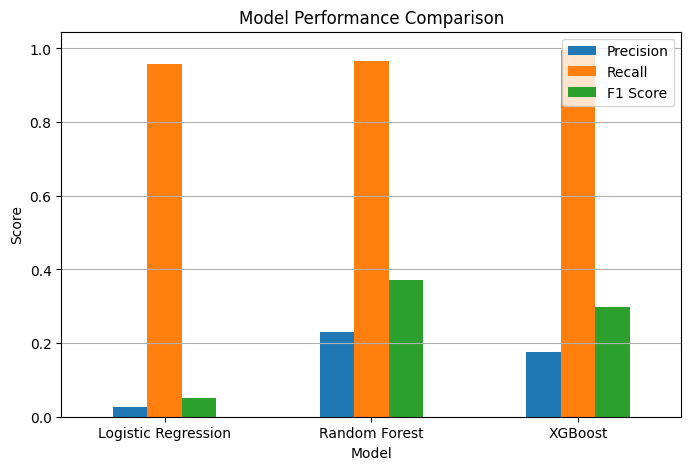

In [26]:
import matplotlib.pyplot as plt

plot_df = results.set_index("Model")

plot_df[["Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

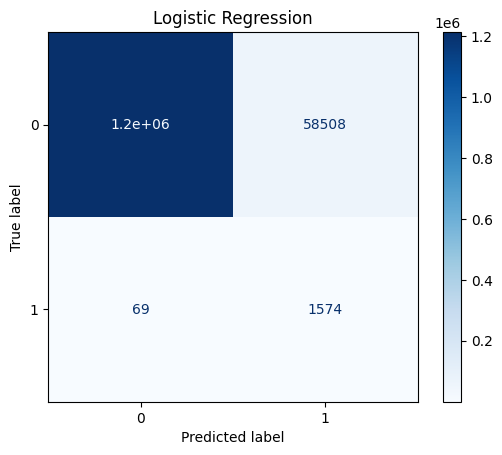

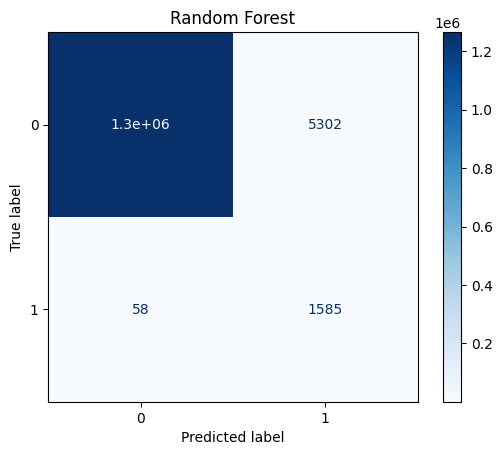

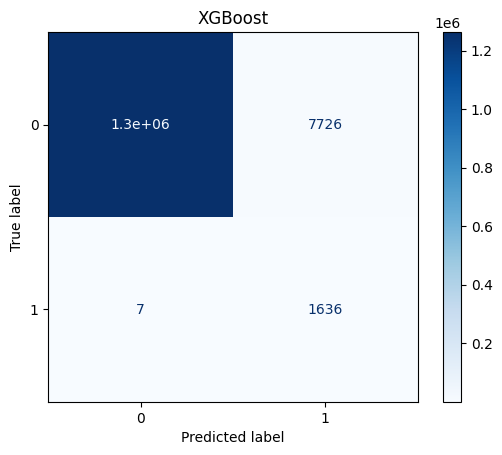

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]

for name, pred in models:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        cmap="Blues"
    )
    plt.title(name)
    plt.show()

<Figure size 800x600 with 0 Axes>

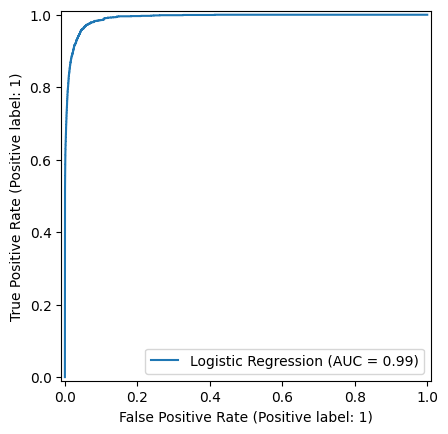

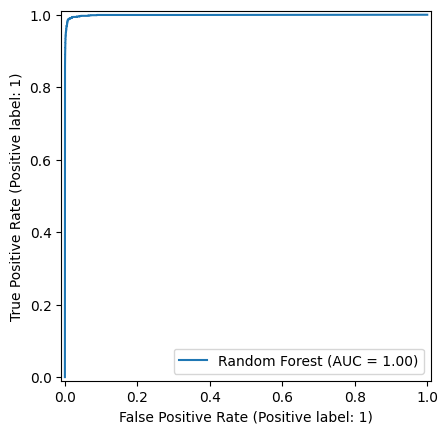

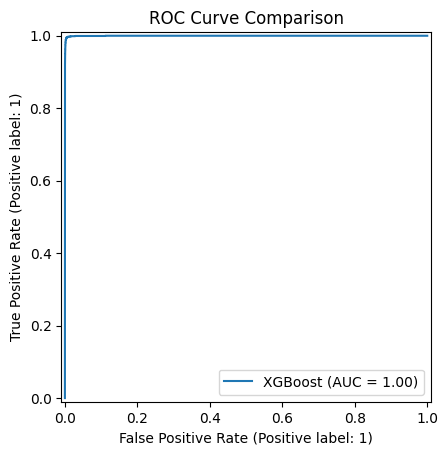

In [28]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
X_train_tune, _, y_train_tune, _ = train_test_split(
    X_train,y_train,train_size=500000,
    stratify=y_train,random_state=42)

print(X_train_tune.shape)
print(y_train_tune.value_counts())

(500000, 8)
isFraud
0    499355
1       645
Name: count, dtype: int64


# Hyperparameter Tuning

RandomizedSearchCV is used to optimize model performance by searching across different combinations of hyperparameters using cross-validation.

In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    "model__n_estimators": [100, 200,300],
    "model__max_depth": [10, 20,None],
    "model__min_samples_split": [2, 5,10],
    "model__min_samples_leaf": [1,2,4],
    "model__max_features": ["sqrt","log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid_rf,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

rf_search.fit(X_train_tune, y_train_tune)

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV F1:")
print(rf_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}

Best CV F1:
0.871524640898111


In [31]:
best_rf = rf_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:,1]

In [32]:
print("Accuracy :", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall   :", recall_score(y_test, y_pred_best_rf))
print("F1 Score :", f1_score(y_test, y_pred_best_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best_rf))

Accuracy : 0.9996903791205509
Precision: 0.9602063375092115
Recall   : 0.7930614729153986
F1 Score : 0.8686666666666667
ROC AUC  : 0.9984727269119917


In [33]:
param_grid_xgb = {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[4,6,8],
    "model__learning_rate":[0.01,0.05,0.1],
    "model__subsample":[0.8,1.0],
    "model__colsample_bytree":[0.8,1.0],
    "model__min_child_weight":[1,3,5]
}

In [34]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid_xgb,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(X_train_tune, y_train_tune)

print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1:")
print(xgb_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

Best CV F1:
0.8575458937816575


In [35]:
best_xgb = xgb_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:,1]

In [36]:
print("Accuracy :", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb))
print("Recall   :", recall_score(y_test, y_pred_best_xgb))
print("F1 Score :", f1_score(y_test, y_pred_best_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best_xgb))

Accuracy : 0.9995622872338753
Precision: 0.7983516483516484
Recall   : 0.884357881923311
F1 Score : 0.8391568004620271
ROC AUC  : 0.9990158580322954


In [43]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb),
        accuracy_score(y_test,y_pred_best_rf),
        accuracy_score(y_test,y_pred_best_xgb)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_xgb),
        precision_score(y_test,y_pred_best_rf),
        precision_score(y_test,y_pred_best_xgb)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_xgb),
        recall_score(y_test,y_pred_best_rf),
        recall_score(y_test,y_pred_best_xgb)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_xgb),
        f1_score(y_test,y_pred_best_rf),
        f1_score(y_test,y_pred_best_xgb)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_xgb),
        roc_auc_score(y_test,y_prob_best_rf),
        roc_auc_score(y_test,y_prob_best_xgb)
    ]

})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9540,0.0262,0.9580,0.0510,0.9917
1,Random Forest,0.9958,0.2301,0.9647,0.3716,0.9989
2,XGBoost,0.9939,0.1747,0.9957,0.2973,0.9998
3,Tuned Random Forest,0.9997,0.9602,0.7931,0.8687,0.9985
4,Tuned XGBoost,0.9996,0.7984,0.8844,0.8392,0.9990


# Model Selection

Among all evaluated models, the tuned Random Forest achieved the best overall balance between Precision, Recall, F1-score, and ROC-AUC. Therefore, it was selected as the final model for deployment.

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf_search.best_estimator_.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1270827      54]
 [    340    1303]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.96      0.79      0.87      1643

    accuracy                           1.00   1272524
   macro avg       0.98      0.90      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



In [39]:
print(rf_search.best_params_)
print(xgb_search.best_params_)

{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


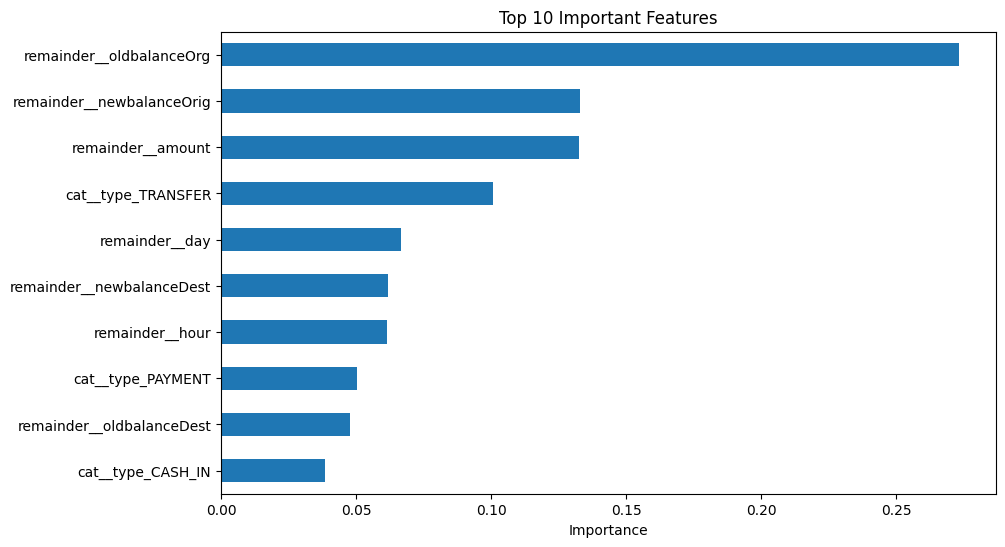

In [40]:
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importance = pd.Series(
    best_rf.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.show()

## Interpretation

Balance-related variables contribute most to the model's predictions.
Transaction type and transaction amount are also influential predictors.
These findings are consistent with patterns observed during exploratory data analysis.

In [41]:
import joblib

joblib.dump(best_rf, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']

# Deployment

The final trained Random Forest pipeline was serialized using Joblib and deployed as an interactive web application using Streamlit.

The application allows users to enter transaction details and obtain fraud predictions in real time.